**1. SETUP AND INITIALIZATION**

In [1]:
!pip install -q torchmetrics

import os
import random
import cv2
import torch
import numpy as np
import torchvision
import math
import sys
import time
import warnings
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN_MobileNet_V3_Large_FPN_Weights
from sklearn.metrics import classification_report, confusion_matrix
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision.transforms.functional as TF

warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

base_path = '/content/drive/MyDrive/COS30018_fall_detection_project'

def collate_fn(batch):
    return tuple(zip(*batch))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 66.5 MB/s eta 0:00:00
Mounted at /content/drive
Using device: cuda


**2. CUSTOM DATASET**

In [ ]:
class FallDetectionDataset(Dataset):
    def __init__(self, img_dir, label_dir, is_train=False):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.is_train = is_train
        self.imgs = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

    def __getitem__(self, idx):
        img_filename = self.imgs[idx]
        img_path = os.path.join(self.img_dir, img_filename)
        img = cv2.imread(img_path)
        if img is None: return self._return_empty(idx)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        orig_h, orig_w, _ = img.shape

        label_filename = img_filename.rsplit('.', 1)[0] + '.txt'
        label_path = os.path.join(self.label_dir, label_filename)
        boxes, labels = [], []

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    data = line.strip().split()
                    if len(data) < 5: continue

                    class_id = int(data[0])
                    # Maps YOLO labels (0,1,2) up by 1 (to 1,2,3).
                    # Two-stage detectors require an explicit Background class. 
                    # This strictly reserves Class 0 for "Background", forcing the model to learn empty space.
                    mapped_class = class_id + 1

                    if len(data) == 5:
                        # Converts YOLO normalized centers (x_c, y_c, w, h) into absolute pixel boundaries (xmin, ymin, xmax, ymax).
                        # torchvision's Faster R-CNN strictly expects bounding boxes to be absolute coordinate points, not normalized centers.
                        x_c, y_c, bw, bh = map(float, data[1:])
                        xmin = max((x_c - bw / 2) * orig_w, 0)
                        ymin = max((y_c - bh / 2) * orig_h, 0)
                        xmax = min((x_c + bw / 2) * orig_w, orig_w)
                        ymax = min((y_c + bh / 2) * orig_h, orig_h)

                        if xmax > xmin and ymax > ymin:
                            boxes.append([xmin, ymin, xmax, ymax])
                            labels.append(mapped_class)

        img_tensor = torch.as_tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0

        # Augmentation adjustments
        if self.is_train and len(boxes) > 0:
            if random.random() > 0.5:
                img_tensor = TF.hflip(img_tensor)
                for box in boxes:
                    new_xmin = orig_w - box[2]
                    new_xmax = orig_w - box[0]
                    box[0], box[2] = new_xmin, new_xmax

            if random.random() > 0.5:
                img_tensor = TF.adjust_brightness(img_tensor, brightness_factor=random.uniform(0.7, 1.3))
                img_tensor = TF.adjust_contrast(img_tensor, contrast_factor=random.uniform(0.7, 1.3))
                img_tensor = TF.adjust_saturation(img_tensor, saturation_factor=random.uniform(0.7, 1.3))

        boxes_t = torch.as_tensor(boxes, dtype=torch.float32).view(-1, 4) if len(boxes) > 0 else torch.zeros((0, 4), dtype=torch.float32)
        labels_t = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "image_id": torch.tensor([idx]),
            "area": (boxes_t[:, 3] - boxes_t[:, 1]) * (boxes_t[:, 2] - boxes_t[:, 0]) if len(boxes) > 0 else torch.zeros((0,), dtype=torch.float32),
            "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64)
        }

        return img_tensor, target

    def _return_empty(self, idx):
        return torch.zeros((3, 640, 640)), {"boxes": torch.zeros((0, 4)), "labels": torch.zeros((0,), dtype=torch.int64), "image_id": torch.tensor([idx]), "area": torch.zeros((0,)), "iscrowd": torch.zeros((0,))}

    def __len__(self): return len(self.imgs)

**3. LABEL STANDARDIZATION (DATA CLEANING)**

In [ ]:
import os
from glob import glob

print("Cleaning dataset labels for Faster R-CNN...")

label_dirs = [
    "/content/drive/MyDrive/COS30018_fall_detection_project/labels/train",
    "/content/drive/MyDrive/COS30018_fall_detection_project/labels/val",
    "/content/drive/MyDrive/COS30018_fall_detection_project/labels/test"
]

for label_dir in label_dirs:
    txt_files = glob(os.path.join(label_dir, "*.txt"))

    for file in txt_files:
        unique_lines = set()

        with open(file, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()

            # Keep only YOLO detection format (5 elements: class x y w h)
            cleaned_line = " ".join(parts[:5])

            # Remove duplicates
            unique_lines.add(cleaned_line)

        # Overwrite the file with clean data
        with open(file, "w") as f:
            f.write("\n".join(unique_lines))

print("✅ Segmentation points removed from R-CNN Drive")
print("✅ Duplicate labels removed from R-CNN Drive")

Cleaning dataset labels for Faster R-CNN...
✅ Segmentation points removed from R-CNN Drive
✅ Duplicate labels removed from R-CNN Drive


In [4]:
for root, dirs, files in os.walk(base_path):
    print(root)

/content/drive/MyDrive/COS30018_fall_detection_project
/content/drive/MyDrive/COS30018_fall_detection_project/images
/content/drive/MyDrive/COS30018_fall_detection_project/images/val
/content/drive/MyDrive/COS30018_fall_detection_project/images/test
/content/drive/MyDrive/COS30018_fall_detection_project/images/train
/content/drive/MyDrive/COS30018_fall_detection_project/labels
/content/drive/MyDrive/COS30018_fall_detection_project/labels/train
/content/drive/MyDrive/COS30018_fall_detection_project/labels/val
/content/drive/MyDrive/COS30018_fall_detection_project/labels/test


**4. MODEL ARCHITECTURE & DATALOADER CONFIGURATION**

In [ ]:
# Setup Datasets
dataset_train = FallDetectionDataset(os.path.join(base_path, 'images/train'), os.path.join(base_path, 'labels/train'), is_train=True)
dataset_val = FallDetectionDataset(os.path.join(base_path, 'images/val'), os.path.join(base_path, 'labels/val'), is_train=False)
dataset_test = FallDetectionDataset(os.path.join(base_path, 'images/test'), os.path.join(base_path, 'labels/test'), is_train=False)

# Setup DataLoaders (Added pin_memory=True for faster GPU transfer)
data_loader_train = DataLoader(dataset_train, batch_size=2, shuffle=True, num_workers=0, collate_fn=collate_fn, pin_memory=True)
data_loader_val = DataLoader(dataset_val, batch_size=2, shuffle=False, num_workers=0, collate_fn=collate_fn, pin_memory=True)
data_loader_test = DataLoader(dataset_test, batch_size=2, shuffle=False, num_workers=0, collate_fn=collate_fn, pin_memory=True)

def get_model(num_classes):
    # Loads a pre-trained backbone (MobileNetV3 in this code) and forces images to process at 640x640 resolution to match YOLO constraints.
    # The FPN (Feature Pyramid Network) extracts multi-scale features to locate humans regardless of distance or camera angle.
    model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(
        weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT,
        min_size=640,
        max_size=640
    )
    # Replaces the default COCO 91-class prediction head.
    # It forces the Stage 2 classifier to discard general COCO objects and strictly predict our 4 custom classes
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

# Initialize model with 4 classes (0=Background, 1=Fall, 2=Walk, 3=Sit)
model = get_model(num_classes=4).to(device)
optimizer = torch.optim.SGD([p for p in model.parameters() if p.requires_grad], lr=0.005, momentum=0.9, weight_decay=0.0025)

num_epochs = 50
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
best_model_path = os.path.join(base_path, 'best_frcnn_model.pth')

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


100%|██████████| 74.2M/74.2M [00:00<00:00, 239MB/s]


**5. TWO-STAGE TRAINING & VALIDATION LOOP**

In [ ]:
best_val_map = 0.0
patience = 10
epochs_without_improvement = 0
train_loss_history = []
val_loss_history = []
val_map_history = []

print(f"\n--- Starting Full {num_epochs} Epoch Session (Backbone: MobileNetV3) ---")
for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    if epoch == 0:
        lr_scheduler_warmup = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=1./1000, total_iters=min(1000, len(data_loader_train)-1)
        )

    for images, targets in data_loader_train:
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        train_loss += losses.item()
        if epoch == 0:
            lr_scheduler_warmup.step()

    if epoch > 0:
        lr_scheduler.step()

    val_loss = 0
    map_metric_val = MeanAveragePrecision(iou_type="bbox")

    model.eval()
    with torch.no_grad():
        for images, targets in data_loader_val:
            images = [img.to(device) for img in images]
            outputs = model(images)

            for i, output in enumerate(outputs):
                map_metric_val.update(
                    [{"boxes": output['boxes'].cpu(), "scores": output['scores'].cpu(), "labels": output['labels'].cpu()}],
                    [{"boxes": targets[i]['boxes'].cpu(), "labels": targets[i]['labels'].cpu()}]
                )

    avg_train = train_loss / len(data_loader_train)

    # Faster R-CNN in PyTorch does not calculate validation loss in eval() mode naturally.
    # This will safely output 0.0
    avg_val = val_loss / len(data_loader_val) if len(data_loader_val) > 0 else 0.0

    val_map_results = map_metric_val.compute()
    current_val_map50 = val_map_results['map_50'].item()

    train_loss_history.append(avg_train)
    val_loss_history.append(avg_val)
    val_map_history.append(current_val_map50)

    print(f"Epoch [{epoch+1:02d}] Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | Val mAP@50: {current_val_map50:.4f}")

    if current_val_map50 > best_val_map:
        best_val_map = current_val_map50
        epochs_without_improvement = 0

        torch.save(model.state_dict(), best_model_path)
        print(f" => Saved new best model with mAP@50: {best_val_map:.4f}")

    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epochs")

    torch.cuda.empty_cache()
    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs.")
        break


--- Starting Full 50 Epoch Session (Backbone: MobileNetV3) ---
Epoch [01] Train Loss: 0.7213 | Val Loss: 0.0000 | Val mAP@50: 0.6150
 => Saved new best model with mAP@50: 0.6150
Epoch [02] Train Loss: 0.7289 | Val Loss: 0.0000 | Val mAP@50: 0.7525
 => Saved new best model with mAP@50: 0.7525
Epoch [03] Train Loss: 0.7169 | Val Loss: 0.0000 | Val mAP@50: 0.7237
No improvement for 1 epochs
Epoch [04] Train Loss: 0.7085 | Val Loss: 0.0000 | Val mAP@50: 0.7516
No improvement for 2 epochs
Epoch [05] Train Loss: 0.7156 | Val Loss: 0.0000 | Val mAP@50: 0.6014
No improvement for 3 epochs
Epoch [06] Train Loss: 0.6585 | Val Loss: 0.0000 | Val mAP@50: 0.7746
 => Saved new best model with mAP@50: 0.7746
Epoch [07] Train Loss: 0.6520 | Val Loss: 0.0000 | Val mAP@50: 0.6006
No improvement for 1 epochs
Epoch [08] Train Loss: 0.6578 | Val Loss: 0.0000 | Val mAP@50: 0.7028
No improvement for 2 epochs
Epoch [09] Train Loss: 0.6200 | Val Loss: 0.0000 | Val mAP@50: 0.6392
No improvement for 3 epochs
Epo

**6. INFERENCE, NMS, AND EVALUATION**

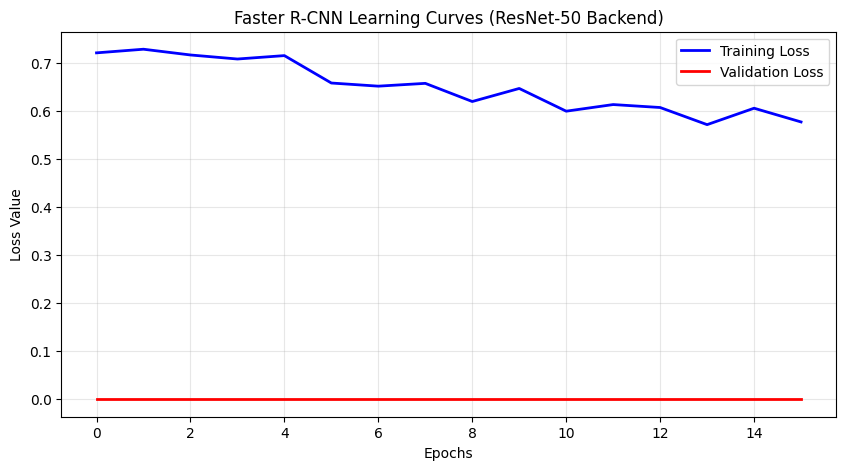

Generating results gallery...


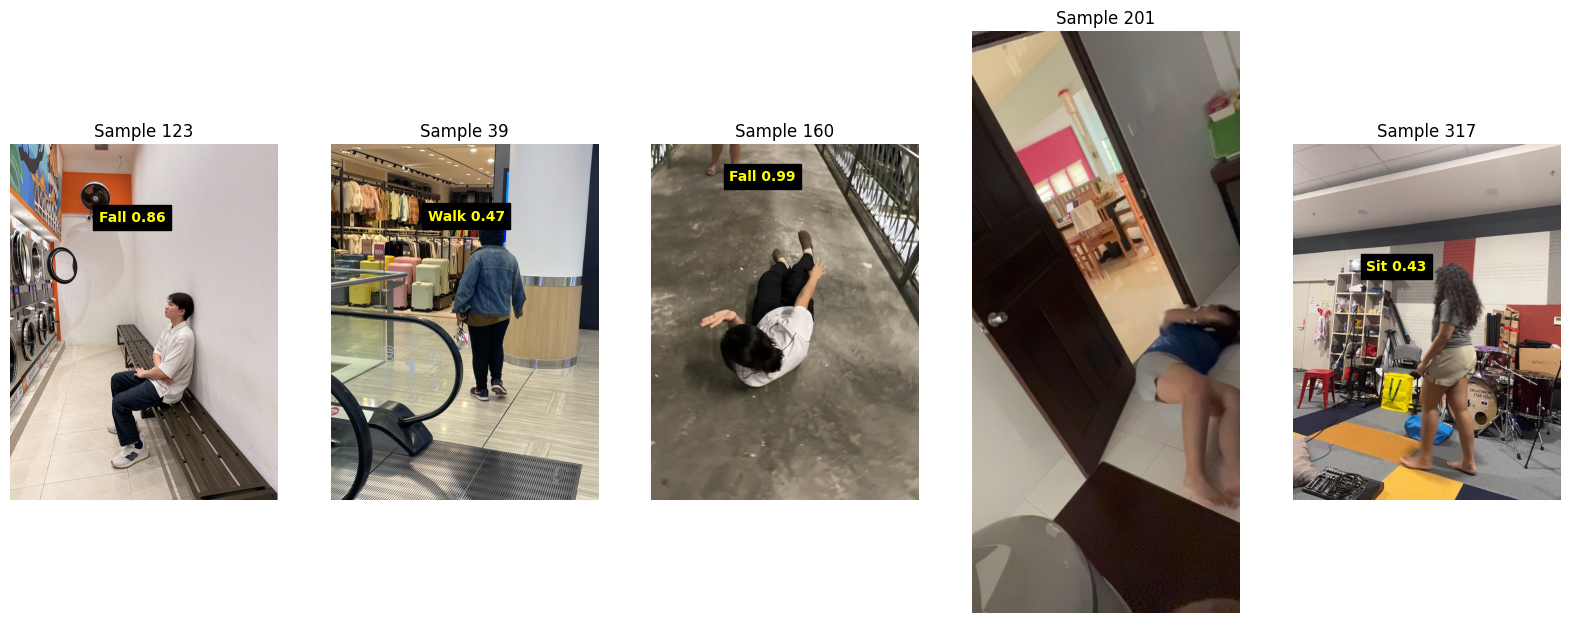


--- Final Evaluation (Conf: 0.3) ---

INFERENCE SPEED: 13.12 ms per image (76.24 FPS)
mAP@0.50:        0.2865
mAP@0.50:0.95:   0.1263


Classification Report:
              precision    recall  f1-score   support

  Background       0.00      0.00      0.00       254
        Fall       0.31      0.56      0.40       176
        Walk       0.42      0.25      0.31       159
         Sit       0.30      0.18      0.22       153

    accuracy                           0.22       742
   macro avg       0.26      0.24      0.23       742
weighted avg       0.23      0.22      0.21       742



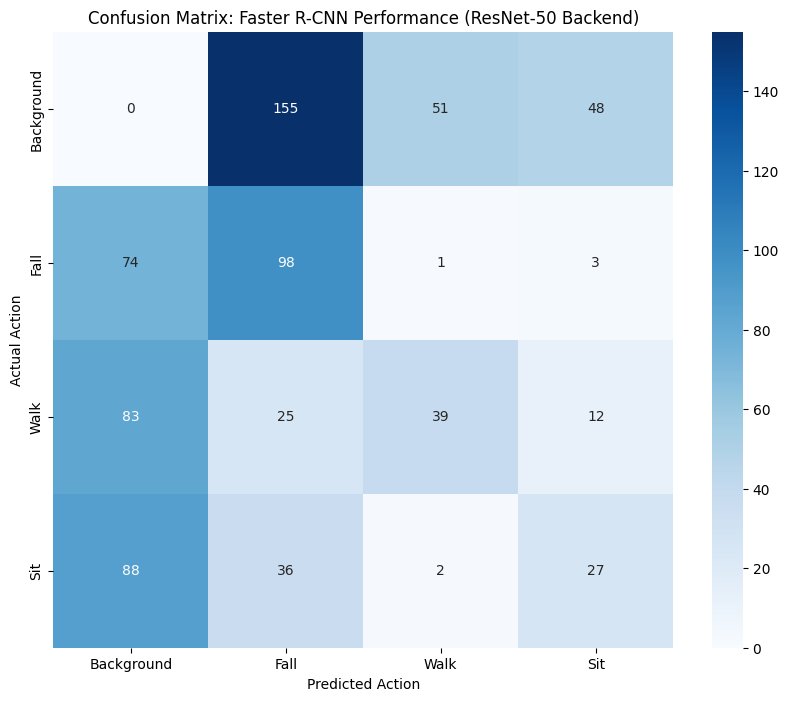

In [ ]:
def plot_curves(train_h, val_h):
    plt.figure(figsize=(10, 5))
    plt.plot(train_h, label='Training Loss', color='blue', lw=2)
    plt.plot(val_h, label='Validation Loss', color='red', lw=2)
    plt.title('Faster R-CNN Learning Curves (ResNet-50 Backend)')
    plt.xlabel('Epochs'); plt.ylabel('Loss Value'); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

def visualize_test_gallery(model, dataset, num_samples=5, conf_threshold=0.3):
    model.eval()
    classes = ['Background', 'Fall', 'Walk', 'Sit']
    colors = [(255, 255, 255), (255, 50, 50), (50, 255, 50), (50, 50, 255)]
    indices = random.sample(range(len(dataset)), num_samples)
    plt.figure(figsize=(20, 10))

    for i, idx in enumerate(indices):
        img_tensor, _ = dataset[idx]
        with torch.no_grad(): output = model([img_tensor.to(device)])[0]

        img = (img_tensor.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8).copy()
        b, l, s = output['boxes'].cpu(), output['labels'].cpu(), output['scores'].cpu()

        keep = s > conf_threshold
        b, l, s = b[keep], l[keep], s[keep]

        # Applies Non-Maximum Suppression (NMS).
        # The RPN generates thousands of boxes, often resulting in multiple overlapping boxes over the same person. NMS deletes overlapping 
        # duplicates (IoU > 0.2) to provide a single, clean detection.
        if len(b) > 0:
            nms_keep = torchvision.ops.nms(b, s, iou_threshold=0.2)
            b, l, s = b[nms_keep], l[nms_keep], s[nms_keep]

        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        plt.title(f"Sample {idx}")
        plt.axis('off')

        for box, lab, sco in zip(b, l, s):
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(img, (x1, y1), (x2, y2), colors[lab], 3)
            plt.text(x1, y1-5, f"{classes[lab]} {sco:.2f}", color='yellow', fontsize=10, fontweight='bold', backgroundcolor='black')

    plt.show()

def evaluate_summary(model, data_loader, iou_threshold=0.5, conf_threshold=0.3):
    model.eval()
    all_true, all_pred = [], []
    total_time = 0.0
    num_images = 0

    map_metric = MeanAveragePrecision(iou_type="bbox")
    print(f"\n--- Final Evaluation (Conf: {conf_threshold}) ---")

    with torch.no_grad():
        for images, targets in data_loader:
            images = [img.to(device) for img in images]

            start_time = time.time()
            outputs = model(images)
            if torch.cuda.is_available(): torch.cuda.synchronize()
            total_time += (time.time() - start_time)
            num_images += len(images)

            for i, output in enumerate(outputs):
                gt_boxes, gt_labels = targets[i]['boxes'].cpu(), targets[i]['labels'].cpu()
                p_boxes, p_labels, p_scores = output['boxes'].cpu(), output['labels'].cpu(), output['scores'].cpu()

                map_metric.update(
                    [{"boxes": p_boxes, "scores": p_scores, "labels": p_labels}],
                    [{"boxes": gt_boxes, "labels": gt_labels}]
                )

                keep = p_scores > conf_threshold
                p_boxes, p_labels = p_boxes[keep], p_labels[keep]

                if len(gt_boxes) == 0 and len(p_boxes) == 0: continue

                # If ground truth was completely missed by the model
                if len(p_boxes) == 0:
                    all_true.extend(gt_labels.tolist())
                    all_pred.extend([0] * len(gt_labels)) # 0 is Background
                    continue

                # If model predicts objects out of thin air on empty ground truth
                if len(gt_boxes) == 0:
                    all_true.extend([0] * len(p_labels))
                    all_pred.extend(p_labels.tolist())
                    continue

                # Handle continuous matching matrix calculation
                ious = torchvision.ops.box_iou(gt_boxes, p_boxes)
                matched_p = set()

                for gt_idx, gt_label in enumerate(gt_labels):
                    best_iou, best_p_idx = -1, -1
                    for p_idx, p_lab in enumerate(p_labels):
                        if p_idx in matched_p: continue
                        iou = ious[gt_idx, p_idx].item()
                        if iou > best_iou:
                            best_iou = iou
                            best_p_idx = p_idx

                    if best_iou >= iou_threshold:
                        all_true.append(gt_label.item())
                        all_pred.append(p_labels[best_p_idx].item())
                        matched_p.add(best_p_idx)
                    else:
                        all_true.append(gt_label.item())
                        all_pred.append(0) # Marked missed localization as Background

                for p_idx, p_lab in enumerate(p_labels):
                    if p_idx not in matched_p:
                        all_true.append(0) # Background false alarm
                        all_pred.append(p_lab.item())

    avg_ms = (total_time / num_images) * 1000
    fps = 1.0 / (total_time / num_images)
    print("\n==========================================")
    print(f"INFERENCE SPEED: {avg_ms:.2f} ms per image ({fps:.2f} FPS)")

    map_results = map_metric.compute()
    print(f"mAP@0.50:        {map_results['map_50']:.4f}")
    print(f"mAP@0.50:0.95:   {map_results['map']:.4f}")
    print("==========================================\n")

    # Lock labels evaluation strictly across all 4 explicit identifiers [0, 1, 2, 3]
    eval_indices = [0, 1, 2, 3]
    target_names = ['Background', 'Fall', 'Walk', 'Sit']

    print("\nClassification Report:")
    print(classification_report(all_true, all_pred, labels=eval_indices, target_names=target_names, zero_division=0))

    # Explicit matrix indexing constraints applied to prevent dimension shifting
    cm = confusion_matrix(all_true, all_pred, labels=eval_indices)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title('Confusion Matrix: Faster R-CNN Performance (ResNet-50 Backend)')
    plt.xlabel('Predicted Action')
    plt.ylabel('Actual Action')
    plt.show()

# EXECUTION
plot_curves(train_loss_history, val_loss_history)
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print("Generating results gallery...")
    visualize_test_gallery(model, dataset_test)
    evaluate_summary(model, data_loader_test)